# Lesson 09 — Confusion Matrix & Evaluation

<h2 dir="rtl">פרק 1 — מהסתברות להחלטה</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

data = pd.read_csv('oring.csv')
data['intercept'] = 1
data['failure'] = (data['num_failure'] >= 1).astype(int)

model = sm.Logit(data['failure'], data[['intercept', 'temp']]).fit(disp=0)
data['p_pred'] = model.predict(data[['intercept', 'temp']])
print(data[['temp', 'failure', 'p_pred']].head(10))

   temp  failure    p_pred
0    66        0  0.406082
1    70        1  0.140566
2    69        0  0.189541
3    68        0  0.250604
4    67        0  0.323488
5    72        0  0.074069
6    73        0  0.052980
7    80        0  0.004556
8    57        1  0.944708
9    63        1  0.666551


<h2 dir="rtl">פרק 2 — Threshold + confusion matrix</h2>

In [2]:
threshold = 0.5
data['y_hat'] = (data['p_pred'] >= threshold).astype(int)

TP = ((data['failure'] == 1) & (data['y_hat'] == 1)).sum()
FP = ((data['failure'] == 0) & (data['y_hat'] == 1)).sum()
FN = ((data['failure'] == 1) & (data['y_hat'] == 0)).sum()
TN = ((data['failure'] == 0) & (data['y_hat'] == 0)).sum()

print(f'Confusion matrix at threshold = {threshold}:')
print(f'                 predicted=0  predicted=1')
print(f'  actual=0   ->  TN = {TN:3d}     FP = {FP:3d}')
print(f'  actual=1   ->  FN = {FN:3d}     TP = {TP:3d}')
print(f'\nTotal: n = {TP + FP + TN + FN}, positives = {TP+FN}, negatives = {TN+FP}')

Confusion matrix at threshold = 0.5:
                 predicted=0  predicted=1
  actual=0   ->  TN =  17     FP =   0
  actual=1   ->  FN =   2     TP =   4

Total: n = 23, positives = 6, negatives = 17


<h2 dir="rtl">פרק 3 — למה accuracy לא מספיק</h2>

In [3]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
print(f'Our model (threshold=0.5):')
print(f'  Accuracy = ({TP}+{TN}) / {TP+TN+FP+FN} = {accuracy:.4f}  ({accuracy*100:.1f}%)')

# Baseline: always predict 0
TN_z = (data['failure'] == 0).sum()
FN_z = (data['failure'] == 1).sum()
accuracy_zero = TN_z / len(data)
print(f'\nBaseline "always predict 0":')
print(f'  TP=0, FP=0, TN={TN_z}, FN={FN_z}')
print(f'  Accuracy = {TN_z}/{len(data)} = {accuracy_zero:.4f}  ({accuracy_zero*100:.1f}%)')
print(f'\nBaseline catches ZERO real failures, yet gets {accuracy_zero*100:.1f}% accuracy.')
print(f'Our model gets {accuracy*100:.1f}% and catches {TP}/{TP+FN}. Accuracy alone is misleading!')

Our model (threshold=0.5):
  Accuracy = (4+17) / 23 = 0.9130  (91.3%)

Baseline "always predict 0":
  TP=0, FP=0, TN=17, FN=6
  Accuracy = 17/23 = 0.7391  (73.9%)

Baseline catches ZERO real failures, yet gets 73.9% accuracy.
Our model gets 91.3% and catches 4/6. Accuracy alone is misleading!


<h2 dir="rtl">פרק 4 — Precision, Recall, F1</h2>

In [4]:
precision = TP / (TP + FP) if (TP + FP) > 0 else float('nan')
recall = TP / (TP + FN) if (TP + FN) > 0 else float('nan')
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f'At threshold = 0.5:')
print(f'  Precision  = TP/(TP+FP) = {TP}/({TP}+{FP}) = {precision:.4f}')
print(f'  Recall     = TP/(TP+FN) = {TP}/({TP}+{FN}) = {recall:.4f}')
print(f'  F1         = 2*P*R/(P+R) = {f1:.4f}')

print()
print('Interpretation:')
print(f'  Precision = {precision:.2f}: when we said "failure", we were right {precision*100:.0f}% of the time.')
print(f'  Recall    = {recall:.2f}: of the {TP+FN} actual failures, we caught {TP} ({recall*100:.0f}%).')
print(f'  F1        = {f1:.2f}: harmonic mean of the two — balances both.')

At threshold = 0.5:
  Precision  = TP/(TP+FP) = 4/(4+0) = 1.0000
  Recall     = TP/(TP+FN) = 4/(4+2) = 0.6667
  F1         = 2*P*R/(P+R) = 0.8000

Interpretation:
  Precision = 1.00: when we said "failure", we were right 100% of the time.
  Recall    = 0.67: of the 6 actual failures, we caught 4 (67%).
  F1        = 0.80: harmonic mean of the two — balances both.


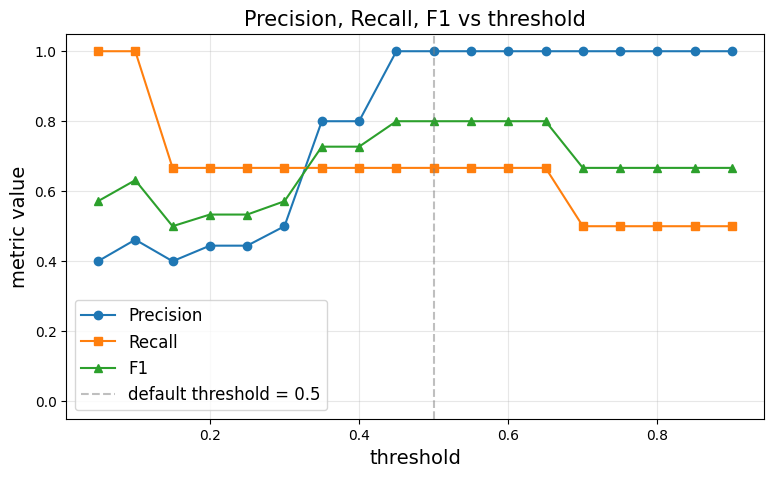

In [5]:
thresholds = np.arange(0.05, 0.95, 0.05)
rows = []
for t in thresholds:
    yhat = (data['p_pred'] >= t).astype(int)
    TP_ = ((data['failure'] == 1) & (yhat == 1)).sum()
    FP_ = ((data['failure'] == 0) & (yhat == 1)).sum()
    FN_ = ((data['failure'] == 1) & (yhat == 0)).sum()
    TN_ = ((data['failure'] == 0) & (yhat == 0)).sum()
    prec = TP_ / (TP_ + FP_) if (TP_ + FP_) > 0 else np.nan
    rec = TP_ / (TP_ + FN_) if (TP_ + FN_) > 0 else 0
    f1_ = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    rows.append({'threshold': t, 'precision': prec, 'recall': rec, 'F1': f1_})
metrics_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(metrics_df['threshold'], metrics_df['precision'], 'o-', color='tab:blue', label='Precision')
ax.plot(metrics_df['threshold'], metrics_df['recall'], 's-', color='tab:orange', label='Recall')
ax.plot(metrics_df['threshold'], metrics_df['F1'], '^-', color='tab:green', label='F1')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='default threshold = 0.5')
ax.set_xlabel('threshold', fontsize=14)
ax.set_ylabel('metric value', fontsize=14)
ax.set_title('Precision, Recall, F1 vs threshold', fontsize=15)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.show()

<h2 dir="rtl">פרק 5 — ROC + AUC</h2>

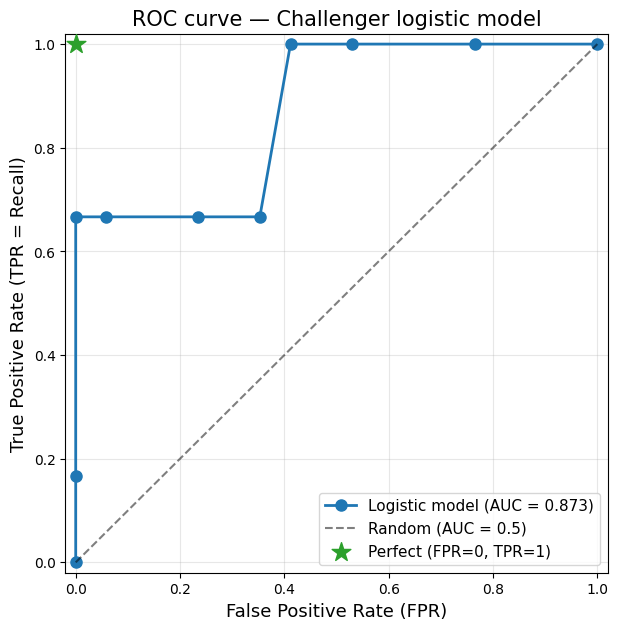

AUC = 0.8725
Interpretation: given a random positive observation and a random negative one,
  there is a 87.3% chance the model assigns higher p_hat to the positive.


In [6]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_vals, tpr_vals, roc_thresholds = roc_curve(data['failure'], data['p_pred'])
auc = roc_auc_score(data['failure'], data['p_pred'])

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr_vals, tpr_vals, 'o-', color='tab:blue', linewidth=2, markersize=8,
        label=f'Logistic model (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.5)')
ax.scatter([0], [1], s=200, color='tab:green', marker='*', zorder=5,
           label='Perfect (FPR=0, TPR=1)')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=13)
ax.set_ylabel('True Positive Rate (TPR = Recall)', fontsize=13)
ax.set_title('ROC curve — Challenger logistic model', fontsize=15)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3)
ax.legend(fontsize=11, loc='lower right')
plt.show()

print(f'AUC = {auc:.4f}')
print(f'Interpretation: given a random positive observation and a random negative one,')
print(f'  there is a {auc*100:.1f}% chance the model assigns higher p_hat to the positive.')

<h2 dir="rtl">פרק 6 — בחירת threshold לפי context</h2>

In [7]:
print('Challenger threshold trade-off:')
print('  cost(FN) >> cost(FP) — losing a shuttle >> delaying a launch.')
print()
print(f'{"threshold":>10}{"TP":>5}{"FP":>5}{"FN":>5}{"recall":>10}{"precision":>11}')
print('-' * 46)
for t in [0.20, 0.30, 0.50, 0.70]:
    yhat = (data['p_pred'] >= t).astype(int)
    TP_ = ((data['failure'] == 1) & (yhat == 1)).sum()
    FP_ = ((data['failure'] == 0) & (yhat == 1)).sum()
    FN_ = ((data['failure'] == 1) & (yhat == 0)).sum()
    rec_ = TP_ / (TP_ + FN_) if (TP_ + FN_) > 0 else 0
    prec_ = TP_ / (TP_ + FP_) if (TP_ + FP_) > 0 else float('nan')
    print(f'{t:>10.2f}{TP_:>5d}{FP_:>5d}{FN_:>5d}{rec_:>10.3f}{prec_:>11.3f}')

Challenger threshold trade-off:
  cost(FN) >> cost(FP) — losing a shuttle >> delaying a launch.

 threshold   TP   FP   FN    recall  precision
----------------------------------------------
      0.20    4    5    2     0.667      0.444
      0.30    4    4    2     0.667      0.500
      0.50    4    0    2     0.667      1.000
      0.70    3    0    3     0.500      1.000


<h2 dir="rtl">פרק 7 — סיכום + הצצה לשיעור 10</h2>

### Write your answer here.

<div dir="rtl">

תרגיל אופציונלי לבית: בבעיית סיווג ספאם (FP = דואר חוקי שנמחק לטעות, FN = ספאם שעובר):

- האם בוחרים threshold נמוך או גבוה?
- למה? מה ההבדל בעלויות?

</div>